# Cost Model Walkthrough And Benefit Plot

This notebook does not prove the full theory from scratch. It builds the README cost model in the same order that a first-time reader is likely to ask for it: degree growth first, per-step work second, combined product count third.

Step 1 is the degree-growth idea. A radix-`r` outer step multiplies the reachable truncation depth by about `r`, so after `k` outer steps you should expect a target degree on the order of `r^k`. Solving that relation for `k` gives the logarithmic step count `k \approx \log_r d`.

Step 2 is the work per outer step. If a kernel itself needs `mu` kernel products and the residual update contributes two more matrix-matrix products, then one outer step costs `mu + 2` products.

Combining the two steps gives the simple library-side cost model

$$(\mu + 2)\lceil \log_r d \rceil,$$

which is the quantity plotted in the README.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_repo_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")


ROOT = find_repo_root()
sys.path.insert(0, str(ROOT / "src"))


In [2]:
from neumann_kernels import kernel_catalog, multiply_count

kernel_catalog()


[{'kernel_id': 'radix5',
  'display_name': 'Radix-5',
  'radix': 5,
  'num_products': 2,
  'status': 'exact',
  'update_cost': 4,
  'asymptotic_coefficient': 1.7227062322935722},
 {'kernel_id': 'radix9',
  'display_name': 'Radix-9',
  'radix': 9,
  'num_products': 3,
  'status': 'exact',
  'update_cost': 5,
  'asymptotic_coefficient': 1.5773243839286437},
 {'kernel_id': 'radix15',
  'display_name': 'Radix-15',
  'radix': 15,
  'num_products': 4,
  'status': 'certified approximate',
  'update_cost': 6,
  'asymptotic_coefficient': 1.5357481488588929},
 {'kernel_id': 'radix24',
  'display_name': 'Radix-24',
  'radix': 24,
  'num_products': 5,
  'status': 'certified approximate',
  'update_cost': 7,
  'asymptotic_coefficient': 1.526730043898721}]

The catalog gives the `(radix, mu)` pairs. The next cell turns those pairs into a direct comparison against naive polynomial evaluation as the target degree grows.

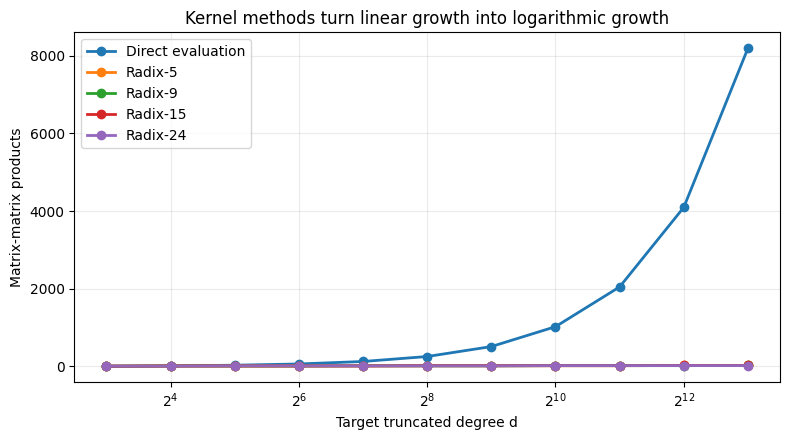

In [3]:
degrees = [2 ** k for k in range(3, 14)]
direct = [degree - 1 for degree in degrees]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, direct, marker="o", linewidth=2, label="Direct evaluation")
for row in kernel_catalog():
    counts = [multiply_count(row["radix"], row["num_products"], degree) for degree in degrees]
    ax.plot(degrees, counts, marker="o", linewidth=2, label=row["display_name"])
ax.set_xscale("log", base=2)
ax.set_xlabel("Target truncated degree d")
ax.set_ylabel("Matrix-matrix products")
ax.set_title("Kernel methods turn linear growth into logarithmic growth")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()


The plot is the main payoff: direct evaluation grows linearly in `d`, while the kernel curves grow only with the logarithm of `d`. The helper script below refreshes the exact PNG embedded in the README.

In [4]:
print("To refresh the README figure, run:")
print("python scripts/plot_benefit.py")


To refresh the README figure, run:
python scripts/plot_benefit.py
